 ## Implementing Gradient Descent Algorithm

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


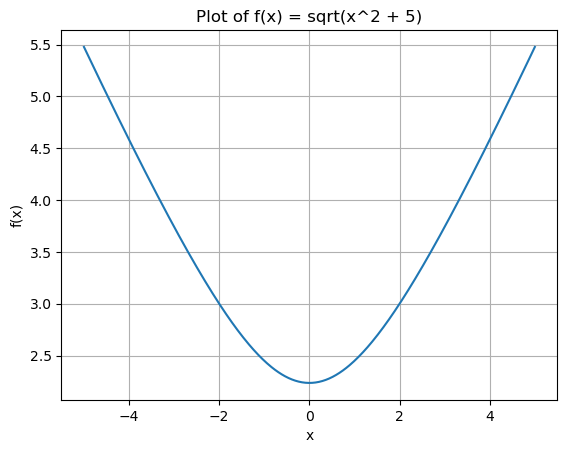

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function f(x).
def f(x):
    return np.sqrt(x**2 + 5)

# Plot the function f(x), np.linspace might be helpful.
x_vals = np.linspace(-5, 5, 400)
y_vals = f(x_vals)

plt.plot(x_vals, y_vals)
plt.title("Plot of f(x) = sqrt(x^2 + 5)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()


In [19]:
# Define the derivative of the function f(x), for gradient descent
def f_grad(x):
    return x / np.sqrt(x**2 + 5)


# write a function to run the Gradient Descent Algorithm, take input arguments x_0, step_size, and num_iterations; return a list/array of x_k values.
def gradient_descent(x0, step_size, num_iterations):
    x_list = [x0]               # store x_k
    f_list = [f(x0)]            # store f(x_k)

    x = x0
    for k in range(num_iterations):
        grad = f_grad(x)        # gradient at current point
        x = x - step_size * grad    # GD update rule
        x_list.append(x)
        f_list.append(f(x))

    return np.array(x_list), np.array(f_list)


In [22]:
# set up/assign initial values
last_digit = 0   
x0 = last_digit / 5 + 1
step_size = 1
num_iterations = 50

print("Initial x0 =", x0)

# Run gradient descent by calling the function
x_hist, f_hist = gradient_descent(x0, step_size, num_iterations)

# report x_T by printing out the value
print("x_T =", x_hist[-1])
print("f(x_T) =", f_hist[-1])


Initial x0 = 1.0
x_T = 1.4949947209933747e-13
f(x_T) = 2.23606797749979


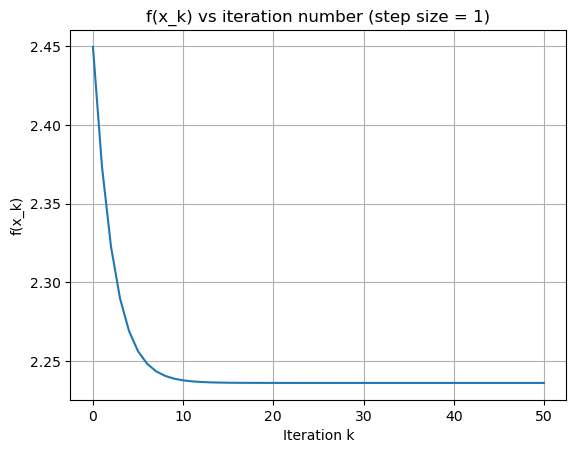

In [26]:
# Plot the f(x_k) values vs. iteration number
plt.plot(f_hist)
plt.title("f(x_k) vs iteration number (step size = 1)")
plt.xlabel("Iteration k")
plt.ylabel("f(x_k)")
plt.grid(True)
plt.show()


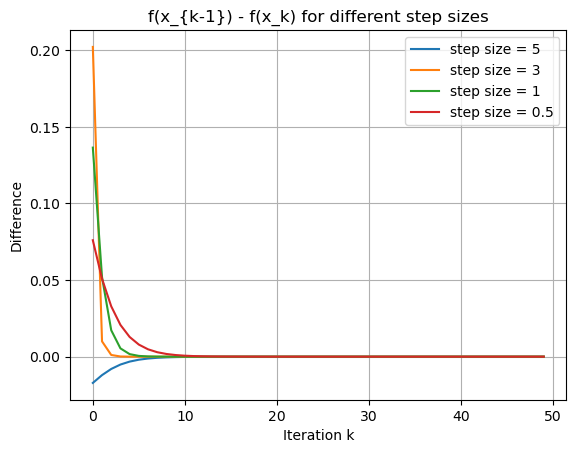

In [24]:
# create a list containing step sizes
step_sizes = [5, 3, 1, 0.5]

# initialize a list to store the results from different step sizes
results = []

# loop through the step sizes and perform GD and record results
x0 = last_digit / 5 + 1
num_iterations = 50

for alpha in step_sizes:
    x_hist, f_hist = gradient_descent(x0, alpha, num_iterations)
    diff_vals = f_hist[:-1] - f_hist[1:]
    
    # store the result
    results.append((alpha, diff_vals))

    plt.plot(diff_vals, label=f"step size = {alpha}")

# plot multiple curves in a single graph
plt.title("f(x_{k-1}) - f(x_k) for different step sizes")
plt.xlabel("Iteration k")
plt.ylabel("Difference")
plt.legend()
plt.grid(True)
plt.show()

## Linear Regression with Numpy and Graphing with Matplotlib

Intercept: 4.07361367634882
Coefficient for X1: 3.8469448945410885
Coefficient for X2: 0.5260806604426167


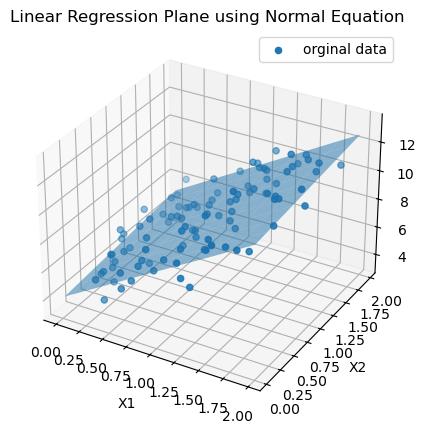

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(10)   # change the seed to be the last two digits of your SB ID.
X = 2 * np.random.rand(100, 2)  # Generate 100 random 2D data points
y = 4 + 4 * X[:, 0] + 0.5 * X[:, 1] + np.random.randn(100)  # Generate y values with noise

# Add a column of ones to X for the bias terms (intercept) in the normal equation
X_b = np.c_[np.ones((100, 1)), X]   # Column of ones + feature columns

# Find theta using the normal equation
# theta = (X^T X)^{-1} X^T y
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

# Print the intercept and coefficients of the regression plane
print("Intercept:", theta[0])
print("Coefficient for X1:", theta[1])
print("Coefficient for X2:", theta[2])

# Plot the generated data and the regression plane
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

# scatter plot
ax.scatter(X[:, 0], X[:, 1], y, label='orginal data')

# grid for regression plane
x1_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 10)
x2_vals = np.linspace(X[:, 1].min(), X[:, 1].max(), 10)
x1_grid, x2_grid = np.meshgrid(x1_vals, x2_vals)

# predicted y on the grid
y_grid = theta[0] + theta[1] * x1_grid + theta[2] * x2_grid

# regression plane
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("y")
ax.set_title("Linear Regression Plane using Normal Equation")
plt.legend()
plt.show()


## Logistic Regression with Numpy and Graphing with Matplotlib

Training Set Accuracy: 0.88
Test Set Accuracy: 1.00


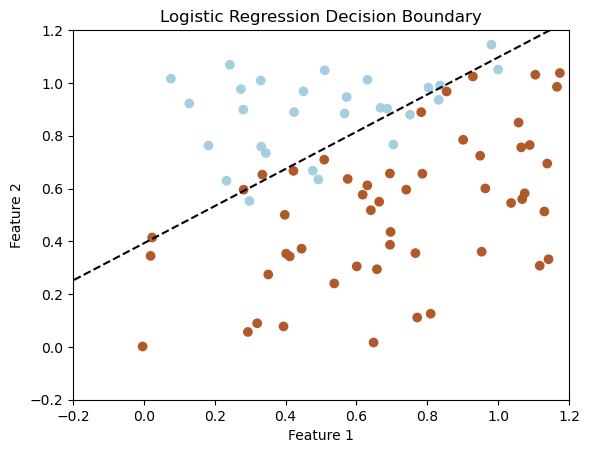

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Define the logistic function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Generate training and testing datasets
np.random.seed(595)             
X = np.random.rand(2, 100)          # 2 features, 100 samples (shape: 2 x 100)

# True parameters to generate synthetic labels
w_true = np.array([1.5, -2.5])
b_true = 1.0

# True model probabilities
probabilities = sigmoid(np.dot(w_true.T, X) + b_true)

# Convert probabilities to binary labels (0 or 1)
Y = (probabilities > 0.5).astype(int)

# Add slight noise so the dataset is not perfectly separable
X = X + 0.3 * np.random.rand(2, 100) - 0.1 * np.random.rand(2, 100)

# Split into train and test sets
X_train, X_test = X[:, :80], X[:, 80:]
Y_train, Y_test = Y[:80], Y[80:]


# Set hyperparameters and initialize parameters
learning_rate = 0.1                 # tuned learning rate
num_epochs = 1000                   # number of iterations

w = np.zeros(X.shape[0])            # initialize weights
b = 0.0                              # initialize bias


# Start training
for epoch in range(num_epochs):

    # Forward pass: compute predictions using current w and b
    A_train = sigmoid(np.dot(w.T, X_train) + b)

    # Compute gradients of the cost function
    dJdw = np.dot(X_train, (A_train - Y_train).T) / len(Y_train)
    dJdb = np.mean(A_train - Y_train)

    # Gradient descent update step
    w -= learning_rate * dJdw
    b -= learning_rate * dJdb


# Calculate training and testing accuracy
A_train = sigmoid(np.dot(w.T, X_train) + b)
A_test  = sigmoid(np.dot(w.T, X_test) + b)

pred_train = (A_train > 0.5).astype(int)
pred_test  = (A_test > 0.5).astype(int)

train_accuracy = np.mean(pred_train == Y_train)
test_accuracy  = np.mean(pred_test == Y_test)

print(f"Training Set Accuracy: {train_accuracy:.2f}")
print(f"Test Set Accuracy: {test_accuracy:.2f}")


# Plot the training dataset and regression decision boundary
plt.scatter(X[0, :80], X[1, :80], c=Y_train, cmap=plt.cm.Paired)
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
ax = plt.gca()

# Make a grid for contouring the decision boundary
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx, yy = np.meshgrid(
    np.linspace(xlim[0], xlim[1], 50),
    np.linspace(ylim[0], ylim[1], 50),
)

# Compute model outputs on the grid
Z = np.dot(w.T, np.c_[xx.ravel(), yy.ravel()].T) + b
Z = sigmoid(Z)
Z = Z.reshape(xx.shape)

# Plot the boundary where predicted probability = 0.5
plt.contour(xx, yy, Z, levels=[0.5], colors='k', linestyles='--')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.show()


In [ ]:
## task 1
